In [75]:
import numpy as np

observations = [8.2, 9.1, 7.7, 8.6, 6.9, 11.2, 10.1, 9.9, 8.9, 9.2, 7.5, 10.5]

xbar = np.mean(observations)
s = np.std(observations, ddof=1)
t = 2.201
n = len(observations)

print(f"sample mean: {xbar}, sample stdev: {s}")
print(f"n: {n}, t: {t}")

margin_of_error = t * s / np.sqrt(n)
print(f"margin of error: {margin_of_error}")

conf_interval = xbar - margin_of_error, xbar + margin_of_error

print(conf_interval)

sample mean: 8.983333333333333, sample stdev: 1.2904074996494381
n: 12, t: 2.201
margin of error: 0.81989133757425
(np.float64(8.163441995759083), np.float64(9.803224670907582))


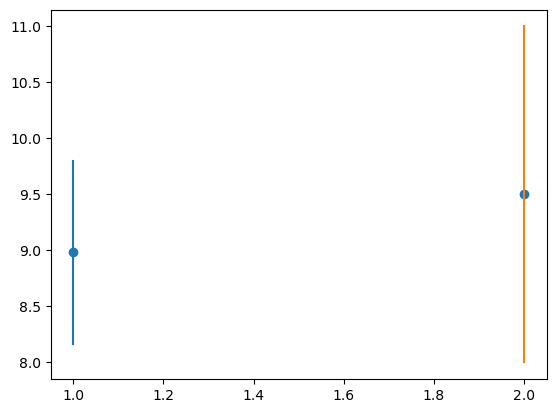

In [76]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter([1, 2], [xbar, 9.5])

plt.plot([1,1], conf_interval)
plt.plot([2,2], [8.0, 11.0])

plt.show()


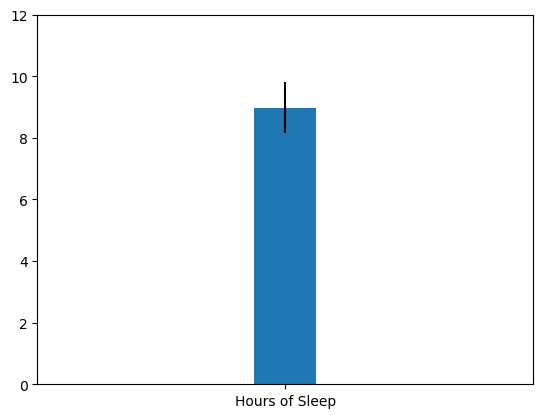

In [77]:
plt.figure()
plt.bar([1], [xbar], yerr = margin_of_error, width=0.25)
plt.xlim([0,2])
plt.ylim([0,12])

plt.xticks([1], ["Hours of Sleep"])

plt.show()

In [78]:
import numpy as np
mpgs = [30,28,32,26,33,25,28,30]
xbar = np.mean(mpgs)
s = np.std(mpgs, ddof=1)
n = len(mpgs)
df = n - 1
t_val = 2.365

t_computed = (xbar - 31)/(s/np.sqrt(n))
print(f"tcomputed: {t_computed}")

if t_computed <= -t_val or t_computed >= t_val:
    print("Reject null hypothesis")
else:
    print("Do not reject null hypothesis")

tcomputed: -2.0367003088692623
Do not reject null hypothesis


In [79]:
import scipy.stats as stats


t_computed, pvalue = stats.ttest_1samp(mpgs,31)

# for 1 tailed test
pvalue = pvalue/2
print(f"tcomputed: {t_computed}")
print(f"pval: {pvalue}")

alpha = 0.05
if pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("Do not reject null hypothesis")

tcomputed: -2.0367003088692623
pval: 0.04055343487369285
Reject the null hypothesis


In [80]:
exp = [61, 102, 119, 128, 62, 158, 271, 57, 266, 137]
cont = [24, 125, 43, 62, 32, 138, 53, 117, 97, 63]

t_crit = 1.734

xbar_exp = np.mean(exp)
xbar_cont = np.mean(cont)

s_exp = np.std(exp, ddof=1)
s_cont = np.std(cont, ddof=1)

n_exp = len(exp)
n_cont = len(cont)

sp2_num = ((n_exp-1)*s_exp**2) + ((n_cont-1)*s_cont**2)
sp2_denom = n_exp + n_cont - 2
sp2 = sp2_num/sp2_denom

t_computed = (xbar_exp-xbar_cont) / np.sqrt(sp2 * (1/n_exp + 1/n_cont))
print(t_computed)


2.1851550736735224


In [81]:
import scipy.stats as stats

t_computed, p_val = stats.ttest_ind(exp, cont)

# when performing a one tailed test, you need to divide the pval by 2
p_val = p_val/2
print(t_computed)
print(p_val)

if p_val < 0.05:
    print("Reject")
else:
    print("do not reject")

2.1851550736735232
0.02117066199247144
Reject


In [82]:
before = [45, 52, 34, 38, 47, 42, 61, 53, 52, 49]
after = [49, 56, 31, 46, 54, 39, 68, 55, 50, 55]

n_before = len(before)
n_after = len(after)
print(n_before)
print(n_after)

diffs = []

for i in range(len(after)):
    diffs.append(after[i]-before[i])

dbar = np.mean(diffs)
sd = np.std(diffs, ddof=1)

sd_bar = sd/np.sqrt(len(diffs))

t_computed = dbar / sd_bar
print(t_computed)

10
10
2.208963121532172


In [83]:
t_computed, p_val = stats.ttest_rel(after, before)
# when performing a one tailed test, you need to divide the pval by 2
p_val = p_val / 2
print(t_computed)
print(p_val)
if p_val < 0.05:
    print("Reject")

2.2089631215321717
0.027268707631662316
Reject
